# SALES FORECASTING

## Objective

To forecast monthly sales for two product categories over the next 36 months using historical data from 2020–2022.

## Import

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

## DATA LOADING

In [2]:
DATA_DIR = Path("./data")

sales = pd.read_excel(DATA_DIR / "2020 - 2022 US Sales.xlsx")
holidays = pd.read_excel(DATA_DIR / "2020 - 2022 US Holidays.xlsx")
oxcgrt = pd.read_csv(DATA_DIR / "OxCGRT_US_latest.csv")

## Sales ETL — Daily Aggregation (Time Index Only)

In [3]:
sales.columns = sales.columns.str.lower().str.replace(" ", "_")
sales["order_date"] = pd.to_datetime(sales["order_date"])

assert sales["subject_category"].nunique() == 2, \
    "Subject Category harus tepat 2"

sales_daily = (
    sales
    .groupby(["order_date", "subject_category"], as_index=False)
    .agg(
        sales_amount=("sales_amount", "sum"),
        sales_quantity=("sales_quantity", "sum")
    )
)

## Holidays (Prophet-Compatible)

In [4]:
holidays = holidays.rename(columns={
    "Date": "ds",
    "Holiday": "holiday"
})
holidays["ds"] = pd.to_datetime(holidays["ds"])

## OxCGRT — StringencyIndex (Mean)

In [5]:
oxcgrt["Date"] = pd.to_datetime(oxcgrt["Date"], format="%Y%m%d")

ox_daily = (
    oxcgrt
    .loc[oxcgrt["CountryName"] == "United States",
         ["Date", "StringencyIndex"]]
    .groupby("Date", as_index=False)
    .agg({"StringencyIndex": "mean"})
)

ox_daily["StringencyIndex"] = ox_daily["StringencyIndex"].round(2)
ox_daily = ox_daily.rename(columns={"Date": "ds"})

In [6]:
full_dates = pd.DataFrame({
    "ds": pd.date_range(
        ox_daily["ds"].min(),
        ox_daily["ds"].max(),
        freq="D"
    )
})

ox_daily = full_dates.merge(ox_daily, on="ds", how="left")
ox_daily["StringencyIndex"] = ox_daily["StringencyIndex"].ffill()

## EXPLORATORY DATA ANALYSIS (EDA)

In [7]:
eda_df = (
    sales_daily
    .merge(ox_daily, left_on="order_date", right_on="ds", how="left")
    .drop(columns="ds")
)

eda_df["StringencyIndex"] = eda_df["StringencyIndex"].ffill()

In [8]:
eda_df

,order_date,subject_category,sales_amount,sales_quantity,StringencyIndex
0,2020-01-01,Medical,37920.81,691,0.00
1,2020-01-01,Science & Technology,30734.01,581,0.00
2,2020-01-02,Medical,72643.01,1425,0.00
3,2020-01-02,Science & Technology,50991.12,1015,0.00
4,2020-01-03,Medical,66033.66,1233,0.00
...,...,...,...,...,...
2187,2022-12-29,Science & Technology,12084.17,240,14.62
2188,2022-12-30,Medical,29989.97,360,14.62
2189,2022-12-30,Science & Technology,11494.15,219,14.62
2190,2022-12-31,Medical,39953.80,419,14.62


### Numerical Feature Correlation

In [9]:
corr_df = (
    eda_df[
        ["sales_amount", "sales_quantity", "StringencyIndex"]
    ]
    .corr()
)

print("Numerical Correlation Matrix:")
print(corr_df)

Numerical Correlation Matrix:
                 sales_amount  sales_quantity  StringencyIndex
sales_amount         1.000000        0.973451         0.123348
sales_quantity       0.973451        1.000000         0.108389
StringencyIndex      0.123348        0.108389         1.000000


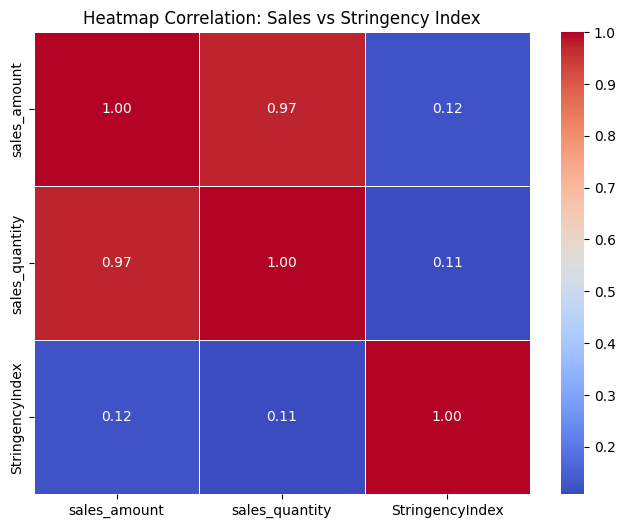

In [10]:
corr_df = eda_df[["sales_amount", "sales_quantity", "StringencyIndex"]].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Heatmap Correlation: Sales vs Stringency Index')
plt.show()

The correlation analysis shows a strong linear relationship between sales amount and sales quantity, which is expected given stable pricing behavior.
The Stringency Index exhibits low linear correlation with sales metrics, indicating it is not a primary demand driver.
However, given its role as a policy shock variable during COVID periods, it is included as an external regressor to capture conditional level shifts rather than global linear dependence.

### Distribution Check (Summary Statistics)

In [11]:
dist_summary = eda_df[
    ["sales_amount", "sales_quantity"]
].describe()

print("Distribution Summary:")
print(dist_summary)

Distribution Summary:
        sales_amount  sales_quantity
count    2192.000000     2192.000000
mean    31580.582432      566.610401
std     21422.786955      388.534476
min      4653.760000       86.000000
25%     17684.652500      301.000000
50%     25818.350000      471.000000
75%     37982.532500      697.250000
max    182034.110000     3171.000000


### Outlier Detection (IQR Method)

In [12]:
# def detect_outliers_iqr(series):
#     q1 = series.quantile(0.25)
#     q3 = series.quantile(0.75)
#     iqr = q3 - q1
#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr
#     return series[(series < lower) | (series > upper)]

# amount_outliers = detect_outliers_iqr(eda_df["sales_amount"])
# qty_outliers = detect_outliers_iqr(eda_df["sales_quantity"])

# print("Sales Amount outliers:", amount_outliers.shape[0])
# print("Sales Quantity outliers:", qty_outliers.shape[0])

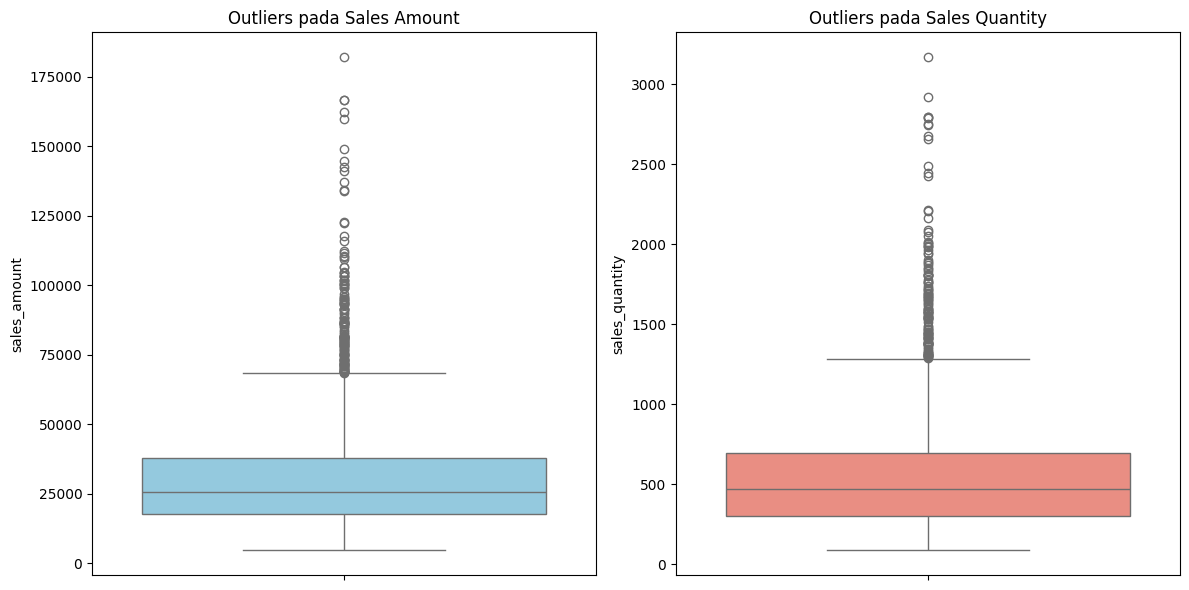

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(y=eda_df["sales_amount"], ax=axes[0], color='skyblue')
axes[0].set_title('Outliers pada Sales Amount')

sns.boxplot(y=eda_df["sales_quantity"], ax=axes[1], color='salmon')
axes[1].set_title('Outliers pada Sales Quantity')

plt.tight_layout()
plt.show()

# Model : Prophet

In [14]:
def train_prophet_daily(df, holidays):
    model = Prophet(
        yearly_seasonality=True,    # captures long-term annual seasonal patterns
        weekly_seasonality=True,    # important for daily data (weekday vs weekend effects)
        daily_seasonality=False,    # high-frequency noise, rarely meaningful for daily sales
        holidays=holidays
    )

    model.add_regressor("StringencyIndex")
    
    model.fit(df)
    return model

In [15]:
def train_val_split(df, ratio=0.8):
    split_idx = int(len(df) * ratio)
    return df.iloc[:split_idx], df.iloc[split_idx:]

### Training, Prediction, Plotting, Evaluation

15:47:45 - cmdstanpy - INFO - Chain [1] start processing
15:47:45 - cmdstanpy - INFO - Chain [1] done processing


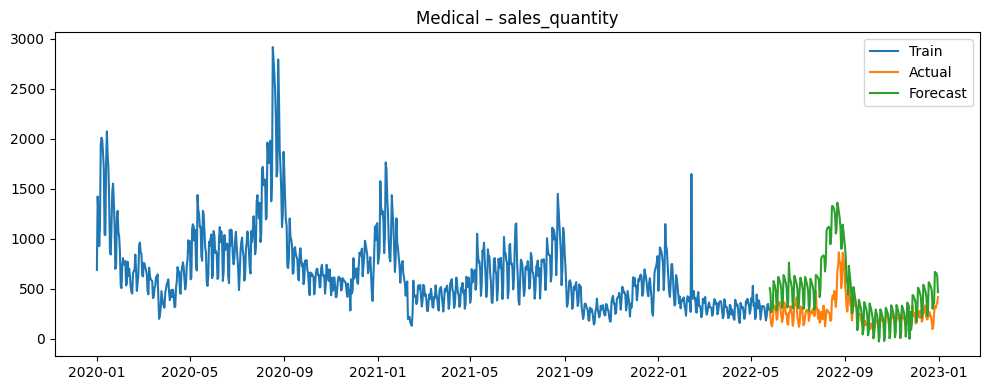

15:47:45 - cmdstanpy - INFO - Chain [1] start processing
15:47:45 - cmdstanpy - INFO - Chain [1] done processing


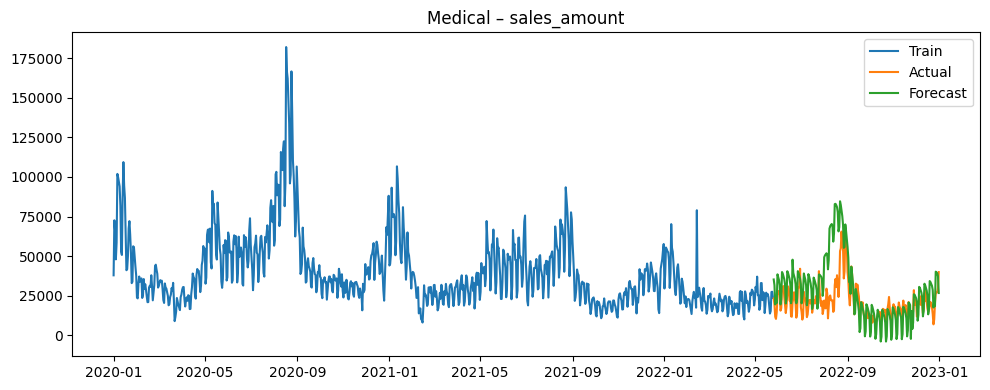

15:47:46 - cmdstanpy - INFO - Chain [1] start processing
15:47:46 - cmdstanpy - INFO - Chain [1] done processing


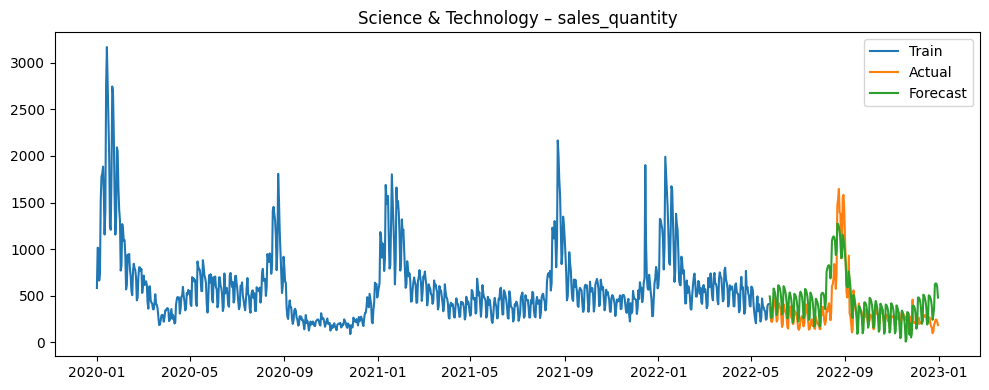

15:47:47 - cmdstanpy - INFO - Chain [1] start processing
15:47:47 - cmdstanpy - INFO - Chain [1] done processing


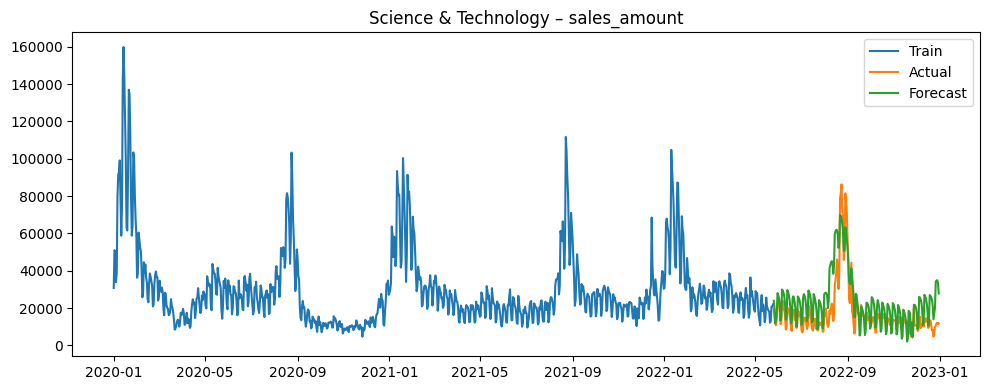

In [16]:
evaluation = []

for category in sales_daily["subject_category"].unique():

    df = sales_daily[sales_daily["subject_category"] == category].copy()

    # Merge Stringency Index
    df = df.merge(
        ox_daily,
        left_on="order_date",
        right_on="ds",
        how="left"
    ).drop(columns="ds")

    df["StringencyIndex"] = df["StringencyIndex"].ffill()

    for target in ["sales_quantity", "sales_amount"]:

        prophet_df = (
            df.rename(columns={
                "order_date": "ds",
                target: "y"
            })[["ds", "y", "StringencyIndex"]]
            .sort_values("ds")
        )

        # 80:20 time-based split
        train, val = train_val_split(prophet_df, 0.8)

        # Train & predict
        model = train_prophet_daily(train, holidays)
        forecast = model.predict(val)

        # --- Evaluation ---
        mae = mean_absolute_error(val["y"], forecast["yhat"])

        mask = val["y"] != 0
        mape = mean_absolute_percentage_error(
            val.loc[mask, "y"].values,
            forecast["yhat"].values[mask.values]
        ) if mask.any() else np.nan

        evaluation.append({
            "subject_category": category,
            "target": target,
            "MAE": mae,
            "MAPE": mape
        })

        # --- Plot ---
        plt.figure(figsize=(10, 4))
        plt.plot(train["ds"], train["y"], label="Train")
        plt.plot(val["ds"], val["y"], label="Actual")
        plt.plot(val["ds"], forecast["yhat"], label="Forecast")
        plt.title(f"{category} – {target}")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [17]:
evaluation_df = pd.DataFrame(evaluation)
evaluation_df

,subject_category,target,MAE,MAPE
0,Medical,sales_quantity,233.136825,0.939860
1,Medical,sales_amount,11153.781309,0.579990
2,Science & Technology,sales_quantity,157.816434,0.570687
3,Science & Technology,sales_amount,8107.814956,0.576349


## Agregasi ke Weekly

In [18]:
sales_weekly = (
    sales_daily
    .assign(week=lambda x: x["order_date"].dt.to_period("W").dt.start_time)
    .groupby(["week", "subject_category"], as_index=False)
    .agg({
        "sales_quantity": "sum",
        "sales_amount": "sum"
    })
    .rename(columns={"week": "ds"})
)

ox_weekly = (
    ox_daily
    .assign(week=lambda x: x["ds"].dt.to_period("W").dt.start_time)
    .groupby("week", as_index=False)["StringencyIndex"]
    .mean()
    .rename(columns={"week": "ds"})
)

## Konfigurasi Model (Weekly)

In [19]:
def train_prophet_weekly(df, holidays):
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,  # weekly data
        daily_seasonality=False,
        holidays=holidays
    )
    model.add_regressor("StringencyIndex")
    model.fit(df)
    return model

15:47:47 - cmdstanpy - INFO - Chain [1] start processing
15:47:47 - cmdstanpy - INFO - Chain [1] done processing


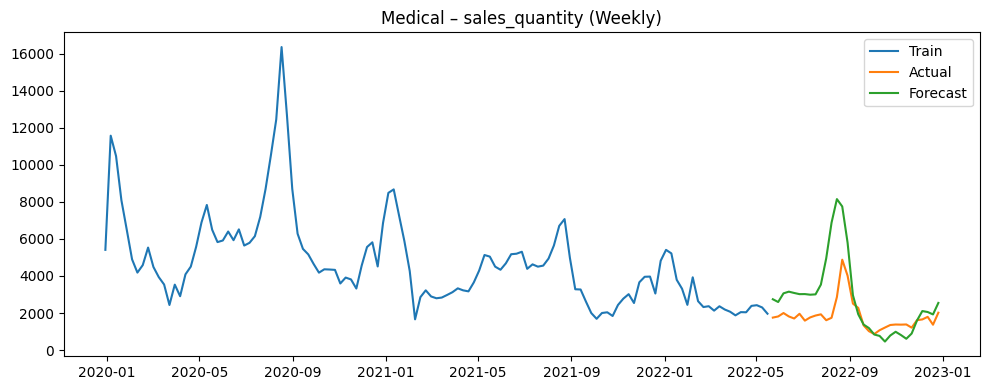

15:47:48 - cmdstanpy - INFO - Chain [1] start processing
15:47:48 - cmdstanpy - INFO - Chain [1] done processing


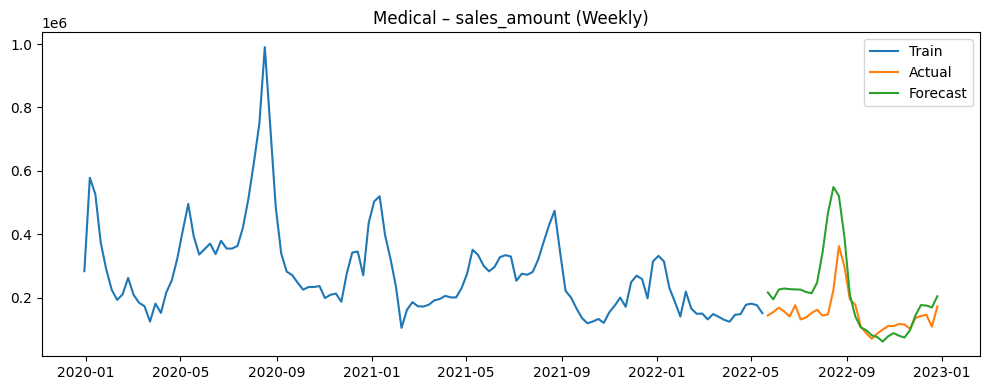

15:47:48 - cmdstanpy - INFO - Chain [1] start processing
15:47:48 - cmdstanpy - INFO - Chain [1] done processing


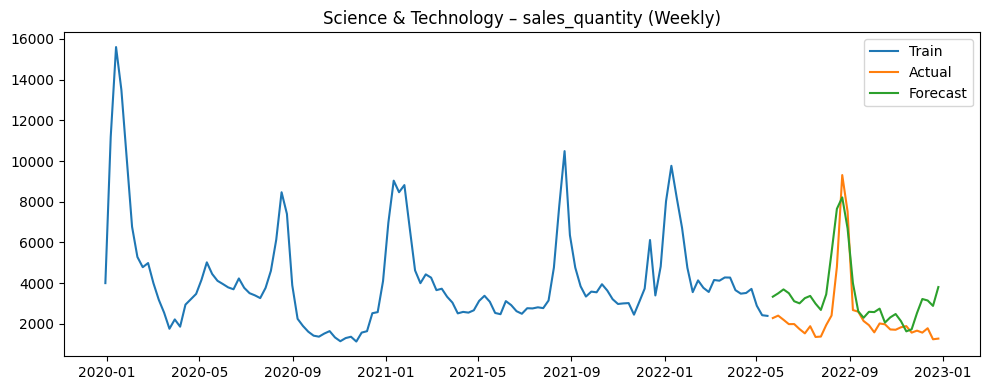

15:47:49 - cmdstanpy - INFO - Chain [1] start processing
15:47:49 - cmdstanpy - INFO - Chain [1] done processing


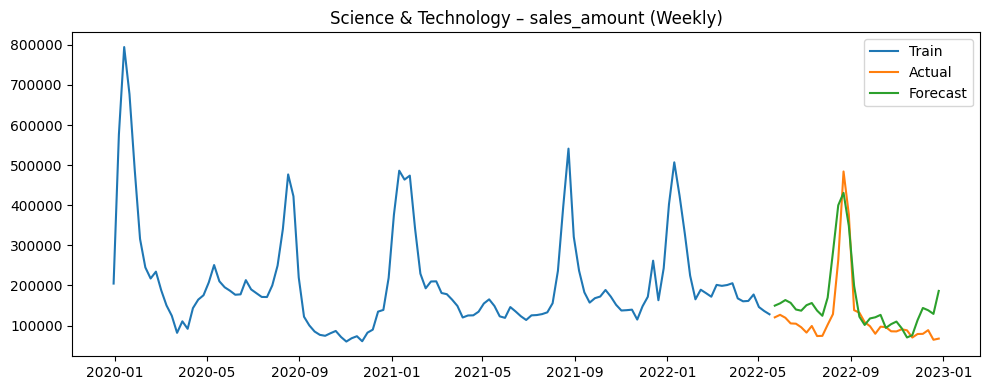

In [20]:
evaluation = []

for category in sales_weekly["subject_category"].unique():

    df = sales_weekly[sales_weekly["subject_category"] == category].copy()

    df = df.merge(ox_weekly, on="ds", how="left")
    df["StringencyIndex"] = df["StringencyIndex"].ffill()

    for target in ["sales_quantity", "sales_amount"]:

        prophet_df = (
            df.rename(columns={target: "y"})[["ds", "y", "StringencyIndex"]]
            .sort_values("ds")
        )

        train, val = train_val_split(prophet_df, 0.8)

        model = train_prophet_weekly(train, holidays)
        forecast = model.predict(val)

        mae = mean_absolute_error(val["y"], forecast["yhat"])

        mask = val["y"] != 0
        mape = mean_absolute_percentage_error(
            val.loc[mask, "y"].values,
            forecast["yhat"].values[mask.values]
        ) if mask.any() else np.nan

        evaluation.append({
            "subject_category": category,
            "target": target,
            "MAE": mae,
            "MAPE": mape
        })

        # Plot
        plt.figure(figsize=(10, 4))
        plt.plot(train["ds"], train["y"], label="Train")
        plt.plot(val["ds"], val["y"], label="Actual")
        plt.plot(val["ds"], forecast["yhat"], label="Forecast")
        plt.title(f"{category} – {target} (Weekly)")
        plt.legend()
        plt.tight_layout()
        plt.show()


In [21]:
evaluation_weekly_df = pd.DataFrame(evaluation)
evaluation_weekly_df

,subject_category,target,MAE,MAPE
0,Medical,sales_quantity,1156.065006,0.596446
1,Medical,sales_amount,69399.482478,0.438828
2,Science & Technology,sales_quantity,1162.235969,0.604858
3,Science & Technology,sales_amount,46233.129661,0.456521


The relatively low accuracy of daily forecasts is primarily driven by high day-to-day volatility during the COVID period (2020–2022). Daily sales are heavily influenced by irregular demand shocks, such as sudden policy changes, panic buying, and supply disruptions, which are not fully captured by smooth trend and seasonality components.

Additionally, daily granularity amplifies noise, especially for sales quantity where many observations are small or zero, leading to inflated relative errors (e.g., MAPE). As a result, daily forecasts tend to reflect directional trends rather than precise point estimates, making them less reliable than aggregated (weekly) forecasts.

## Forecast (3 Years = 156 Weeks)

In [22]:
FORECAST_WEEKS = 156

## Final Forecasting Pipeline (Weekly, Full Data)

In [23]:
final_forecast = []

for category in sales_weekly["subject_category"].unique():

    df = sales_weekly[sales_weekly["subject_category"] == category].copy()

    # merge weekly Stringency Index
    df = df.merge(ox_weekly, on="ds", how="left")
    df["StringencyIndex"] = df["StringencyIndex"].ffill()

    for target in ["sales_quantity", "sales_amount"]:

        prophet_df = (
            df.rename(columns={target: "y"})[["ds", "y", "StringencyIndex"]]
            .sort_values("ds")
        )

        # Train on FULL history
        model = train_prophet_weekly(prophet_df, holidays)

        # Future dataframe (3 years weekly)
        future = model.make_future_dataframe(
            periods=FORECAST_WEEKS,
            freq="W"
        )

        # Extend regressor (assume last known policy level)
        future = future.merge(
            prophet_df[["ds", "StringencyIndex"]],
            on="ds",
            how="left"
        )

        future["StringencyIndex"] = future["StringencyIndex"].ffill()

        forecast = model.predict(future)

        # Keep only future horizon
        forecast_out = forecast.tail(FORECAST_WEEKS)[
            ["ds", "yhat", "yhat_lower", "yhat_upper"]
        ]

        forecast_out["subject_category"] = category
        forecast_out["target"] = target

        final_forecast.append(forecast_out)

15:47:49 - cmdstanpy - INFO - Chain [1] start processing
15:47:49 - cmdstanpy - INFO - Chain [1] done processing
15:47:49 - cmdstanpy - INFO - Chain [1] start processing
15:47:49 - cmdstanpy - INFO - Chain [1] done processing
15:47:50 - cmdstanpy - INFO - Chain [1] start processing
15:47:50 - cmdstanpy - INFO - Chain [1] done processing
15:47:50 - cmdstanpy - INFO - Chain [1] start processing
15:47:50 - cmdstanpy - INFO - Chain [1] done processing


### Final Output

In [24]:
forecast_df = pd.concat(final_forecast, ignore_index=True)

forecast_df = forecast_df.rename(columns={
    "ds": "week",
    "yhat": "forecast",
    "yhat_lower": "lower_bound",
    "yhat_upper": "upper_bound"
})

forecast_df

,week,forecast,lower_bound,upper_bound,subject_category,target
0,2023-01-01,3221.019696,1790.737911,4742.089176,Medical,sales_quantity
1,2023-01-08,4551.841490,3096.326892,5924.632226,Medical,sales_quantity
2,2023-01-15,4629.422316,3109.487678,6051.727312,Medical,sales_quantity
3,2023-01-22,3115.293372,1687.342318,4502.062492,Medical,sales_quantity
4,2023-01-29,1009.085837,-358.142302,2469.021983,Medical,sales_quantity
...,...,...,...,...,...,...
619,2025-11-23,-47387.425800,-112357.689705,14742.580530,Science & Technology,sales_amount
620,2025-11-30,-17639.752621,-75920.161811,37375.332565,Science & Technology,sales_amount
621,2025-12-07,-5819.711621,-66911.116086,55825.701989,Science & Technology,sales_amount
622,2025-12-14,-19758.903672,-78381.868268,41368.987094,Science & Technology,sales_amount


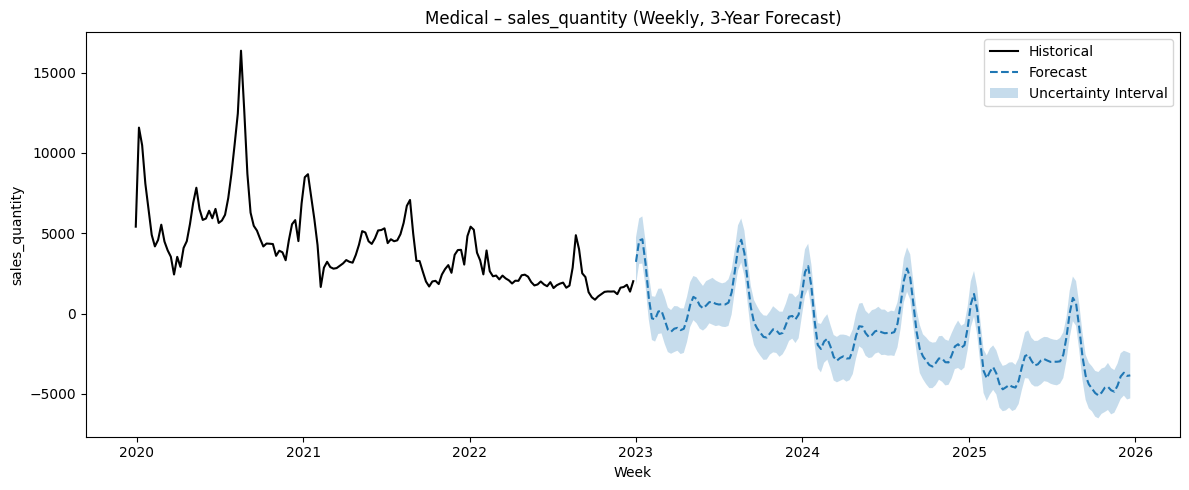

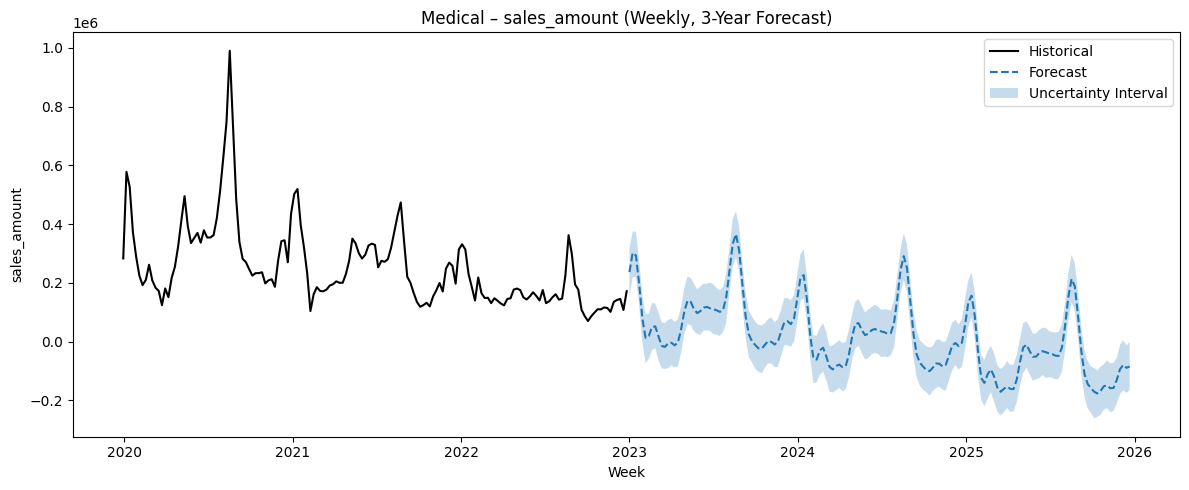

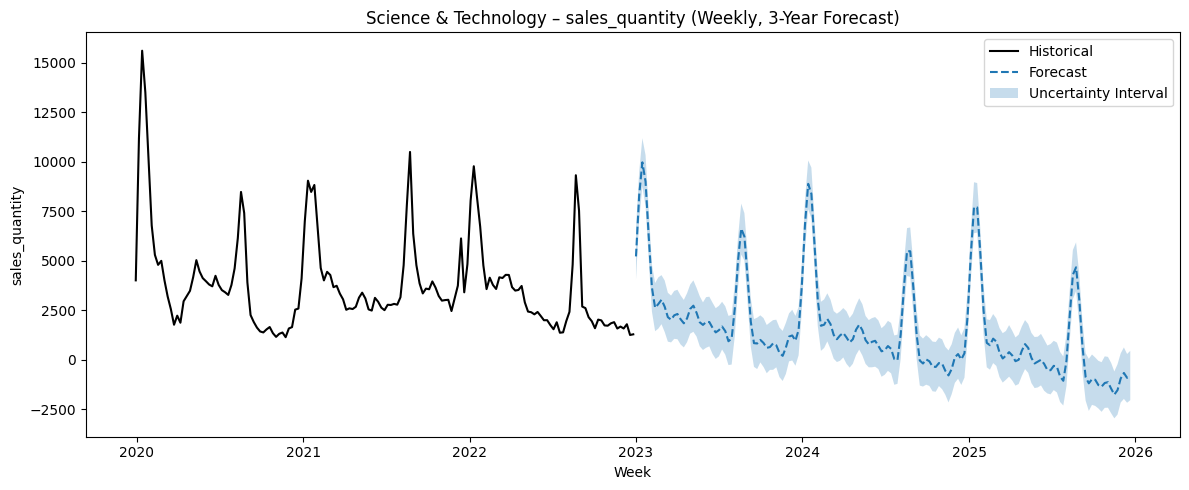

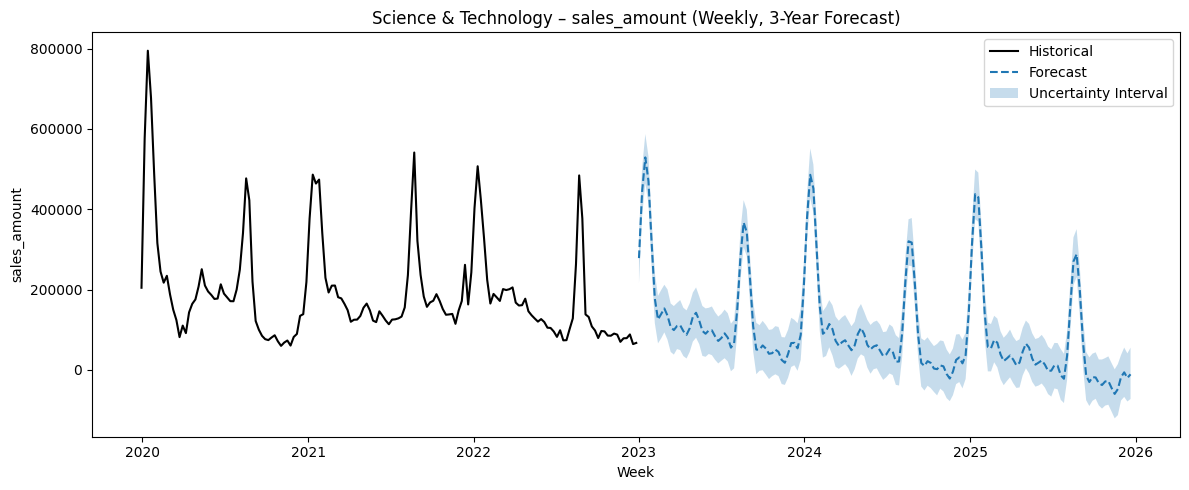

In [25]:
for category in forecast_df["subject_category"].unique():
    for target in ["sales_quantity", "sales_amount"]:

        hist = sales_weekly[sales_weekly["subject_category"] == category]
        hist = hist[["ds", target]].rename(columns={target: "actual"})

        fut = forecast_df[
            (forecast_df["subject_category"] == category) &
            (forecast_df["target"] == target)
        ]

        plt.figure(figsize=(12, 5))

        # Historical
        plt.plot(hist["ds"], hist["actual"], label="Historical", color="black")

        # Forecast
        plt.plot(fut["week"], fut["forecast"], label="Forecast", linestyle="--")

        # Uncertainty interval
        plt.fill_between(
            fut["week"],
            fut["lower_bound"],
            fut["upper_bound"],
            alpha=0.25,
            label="Uncertainty Interval"
        )

        plt.title(f"{category} – {target} (Weekly, 3-Year Forecast)")
        plt.xlabel("Week")
        plt.ylabel(target)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [26]:
forecast_df.to_csv(
    "weekly_forecast_3y.csv",
    index=False
)

In [27]:
with pd.ExcelWriter("weekly_forecast_3y.xlsx", engine="openpyxl") as writer:
    forecast_df.to_excel(
        writer,
        sheet_name="forecast",
        index=False
    )
